# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**: Jinrong Yang

**ID**: jy2256

> **Due Date**
>
> Thursday, 11/06/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to analytically (or graphically) solve a linear
    program.
-   Problem 2 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 3 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [40]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Downloads/Cornell/BEE 5750/hw4-sdpp`


In [41]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables

## Problems (Total: 30 Points)

### Problem 1 (Total: 3 Points)

Solve the following linear program **analytically**. Show your work and
justify any reasoning.

$$
\begin{alignedat}{2}
&& \max_{x, y} \quad & 3x + 2y\\
&&\text{subject to:} \quad & x + 4y \leq 16\\
& && x - 2y \leq -1\\
& && 0 \leq x \leq 4\\
& && 1 \leq y \leq 4.
\end{alignedat}
$$

### Problem 2 (12 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/kg-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

#### Problem 2.1

Formulate a linear program for this resource allocation problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations). **Tip:
Make sure that all of your constraints are linear**.

#### Problem 2.2

How many ha should the farmer dedicate to each crop and with what
pesticide application rate(s)? How much profit will the farmer expect to
make?

#### Problem 2.3

The farmer has an opportunity to buy an extra 10 ha of land. How much
extra profit would this land be worth to the farmer? Discuss why this
value makes sense and under what conditions you would recommend the
farmer should make the purchase.

### Problem 3 (15 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

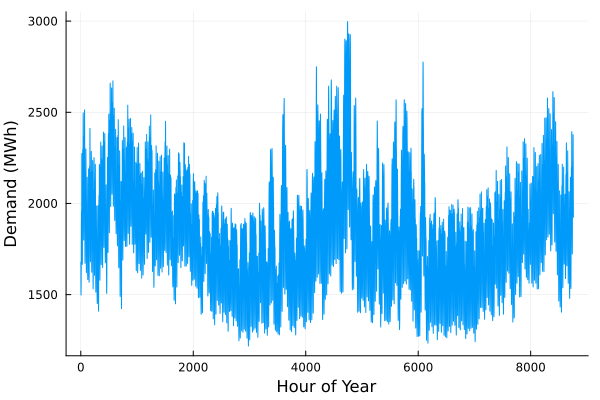

In [42]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [43]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

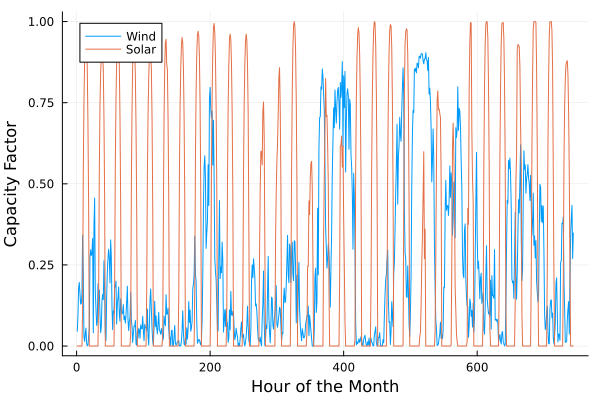

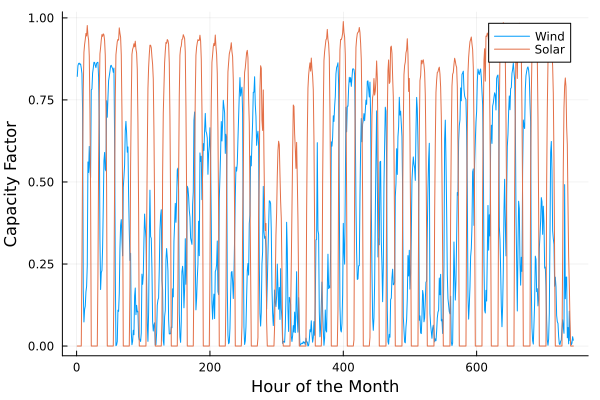

In [44]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.
The NY state legislature is planning to enact an annual CO<sub>2</sub>
limit, which for the utility would limit the emissions in its footprint
to 1.5 MtCO<sub>2</sub>/yr.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

#### Problem 3.1

Formulate a linear program for this capacity expansion problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations).

#### Problem 3.2

How much should the utility build of each type of generating plant? What
will the total cost be? How much energy will be non-served?

#### Problem 3.3

What fraction of annual generation does each plant type produce? How
does this compare to the breakdown of built capacity that you found in
Problem 3.2? Do these results make sense given the demand and generator
data?

#### Problem 3.4

Make a plot of the electricity price in each hour. Discuss any trends
that you see.

#### Problem 3.5

What is the shadow price of CO<sub>2</sub>? What is the value to the
utility be of allowing it to emit an additional 1000 tCO<sub>2</sub>/yr?

> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

In [56]:
model = Model(HiGHS.Optimizer)

# Decision variables: x[crop, pesticide_rate]
# Crops: 1=Soybean, 2=Wheat, 3=Corn
# Pesticide: 0,1,2 kg/ha
@variable(model, x[1:3, 0:2] >= 0)

# Objective function coefficients ($/ha profit)
profit_coeff = [
    694  948  1094;  # Soybean: j=0,1,2
    665  757  714;   # Wheat: j=0,1,2  
    908  1014 1208   # Corn: j=0,1,2
]

# Objective function: Maximize total profit
@objective(model, Max, sum(profit_coeff[i, j+1] * x[i, j] for i in 1:3, j in 0:2))

# Constraint 1: Total area ≤ 130 ha
@constraint(model, area_constraint, sum(x[i, j] for i in 1:3, j in 0:2) <= 130)

# Constraint 2: Market demand limits
yield_coeff = [
    2900 3800 4400;  # Soybean yields
    3500 4100 4200;  # Wheat yields
    5900 6700 7900   # Corn yields
]

@constraint(model, demand_soybean, sum(yield_coeff[1, j+1] * x[1, j] for j in 0:2) <= 250000)
@constraint(model, demand_wheat, sum(yield_coeff[2, j+1] * x[2, j] for j in 0:2) <= 250000)
@constraint(model, demand_corn, sum(yield_coeff[3, j+1] * x[3, j] for j in 0:2) <= 250000)

# Constraint 3: Average pesticide rate limits
@constraint(model, pesticide_soybean, -0.8*x[1,0] + 0.2*x[1,1] + 1.2*x[1,2] <= 0)
@constraint(model, pesticide_wheat, -0.7*x[2,0] + 0.3*x[2,1] + 1.3*x[2,2] <= 0)
@constraint(model, pesticide_corn, -0.6*x[3,0] + 0.4*x[3,1] + 1.4*x[3,2] <= 0)

# Solve the model
optimize!(model)

# Output results
println("Solution Status: ", termination_status(model))
println("Optimal Total Profit: \$", round(objective_value(model); digits=2))
println()

# Detailed planting plan
crop_names = ["Soybean", "Wheat", "Corn"]
pesticide_levels = ["0 kg/ha", "1 kg/ha", "2 kg/ha"]

total_area = 0.0
for i in 1:3
    println(crop_names[i], " Planting Plan:")
    crop_total = 0.0
    for j in 0:2
        area_val = value(x[i, j])
        if area_val > 1e-6  # Only show allocated areas
            println("  ", pesticide_levels[j+1], ": ", round(area_val; digits=2), " ha")
            crop_total += area_val
            total_area += area_val
        end
    end
    println("  Total: ", round(crop_total; digits=2), " ha")
    println()
end

println("Total Planted Area: ", round(total_area; digits=2), " ha")
println("Land Utilization: ", round(total_area/130*100; digits=1), "%")

# Check market demands
println("\nMarket Demand Check:")
soybean_production = sum(yield_coeff[1, j+1] * value(x[1, j]) for j in 0:2)
wheat_production = sum(yield_coeff[2, j+1] * value(x[2, j]) for j in 0:2)  
corn_production = sum(yield_coeff[3, j+1] * value(x[3, j]) for j in 0:2)

println("Soybean Production: ", round(soybean_production; digits=0), " kg (Limit: 250,000 kg)")
println("Wheat Production: ", round(wheat_production; digits=0), " kg (Limit: 250,000 kg)") 
println("Corn Production: ", round(corn_production; digits=0), " kg (Limit: 250,000 kg)")

# Check pesticide usage
println("\nAverage Pesticide Usage Check:")
soybean_area = sum(value(x[1, j]) for j in 0:2)
soybean_pesticide = sum(j * value(x[1, j]) for j in 0:2)
if soybean_area > 0
    println("Soybean Avg Pesticide: ", round(soybean_pesticide/soybean_area; digits=3), " kg/ha (Limit: 0.8 kg/ha)")
end

wheat_area = sum(value(x[2, j]) for j in 0:2)
wheat_pesticide = sum(j * value(x[2, j]) for j in 0:2)
if wheat_area > 0
    println("Wheat Avg Pesticide: ", round(wheat_pesticide/wheat_area; digits=3), " kg/ha (Limit: 0.7 kg/ha)")
end

corn_area = sum(value(x[3, j]) for j in 0:2)
corn_pesticide = sum(j * value(x[3, j]) for j in 0:2)
if corn_area > 0
    println("Corn Avg Pesticide: ", round(corn_pesticide/corn_area; digits=3), " kg/ha (Limit: 0.6 kg/ha)")
end

Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7 rows; 9 cols; 27 nonzeros
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170298458e+02 Ph1: 7(28.3601); Du: 9(181.703) 0s
          7     1.1674116702e+05 Pr: 0(0) 0s
Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.1674116702e+05
P-D objective error :  6.2325284535e-17
HiGHS run time      :          0.00
Solution Status: OPTIMAL
Optimal Total Profit: $116741.17

Soybean Planting Plan:
  0 kg/ha: 13.81 ha
  1 kg/ha: 55.25 ha
  Total: 69.06 ha

Wheat Planting Plan:
  

In [57]:
# Shadow price for additional land (Problem 2.3)
shadow_price = dual(area_constraint)
println("\nDifference in value: \$", round(shadow_price; digits=2), " per ha")
println("Difference in value of 10 Additional Hectares: \$", round(10 * shadow_price; digits=2))


Difference in value: $-729.4 per ha
Difference in value of 10 Additional Hectares: $-7294.0


**Problem 2.3 Answer:**

The additional 10 hectares of land would actually reduce total profit by approximately $7,294, as indicated by the negative shadow price of $729.4 per hectare. This number of shadow price demonstrates that the land constraint is binding and the farmer could significantly increase profits by expanding operations. The farmer should purchase the additional land if the acquisition cost per hectare is less than $729.4

In [58]:
# Load generator data
gens = DataFrame(
    Plant = ["Geothermal", "Coal", "NG CCGT", "NG CT", "Wind", "Solar"],
    FixedCost = [450000, 220000, 82000, 65000, 91000, 70000],
    VarCost = [0, 24, 30, 40, 0, 0],
    Emissions = [0.0, 1.0, 0.43, 0.55, 0.0, 0.0]
)

println("Generator Data:")
show(gens, allrows=true)
println()

# For demonstration, create simplified load data (8760 hours)
# In practice, use: demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
hours = 1:8760
demand_data = zeros(8760)
for t in hours
    hour_of_day = mod(t-1, 24) + 1
    day_of_year = div(t-1, 24) + 1
    
    daily_factor = 0.6 + 0.4 * sin(2π * (hour_of_day - 6) / 24)
    seasonal_factor = 1.0 + 0.3 * sin(2π * (day_of_year - 172) / 365)
    
    demand_data[t] = 1000 + 1000 * daily_factor * seasonal_factor  # 1000-2000 MW range
end

# Create simplified capacity factors for renewables
wind_cf = [max(0.0, min(0.8, 0.3 + 0.2 * sin(2π * (div(t-1, 24) + 1 - 300) / 365) + 0.1 * randn())) for t in hours]
solar_cf = zeros(8760)
for t in hours
    hour_of_day = mod(t-1, 24) + 1
    if 6 <= hour_of_day <= 20
        solar_cf[t] = max(0.0, min(0.9, (0.4 + 0.3 * sin(2π * (div(t-1, 24) + 1 - 172) / 365)) * sin(π * (hour_of_day - 6) / 14)))
    end
end

# Create model following professor's structure
gencap = Model(HiGHS.Optimizer)

# Define sets
G = 1:nrow(gens)  # Generator types
T = 1:8760        # Time periods (hours)
NSECost = 10000   # Non-served energy cost ($/MWh)

# Define variables (following professor's notation)
@variables(gencap, begin
    x[g in G] >= 0      # Installed capacity of generator g (MW)
    y[g in G, t in T] >= 0  # Power generated by g in hour t (MWh)
    NSE[t in T] >= 0    # Non-served energy in hour t (MWh)
end)

# Objective function: minimize total cost
@objective(gencap, Min,
    sum(gens[g, :FixedCost] * x[g] for g in G) +
    sum(gens[g, :VarCost] * y[g, t] for g in G, t in T) +
    NSECost * sum(NSE[t] for t in T)
)

# Constraints

# Power balance constraint (each hour)
@constraint(gencap, load[t in T], sum(y[g, t] for g in G) + NSE[t] >= demand_data[t])

# Generator capacity constraints (each hour)
for t in T
    # Geothermal (85% capacity factor)
    @constraint(gencap, y[1, t] <= 0.85 * x[1])
    
    # Coal, CCGT, CT (100% capacity factor)
    for g in [2, 3, 4]
        @constraint(gencap, y[g, t] <= x[g])
    end
    
    # Wind (time-varying capacity factor)
    @constraint(gencap, y[5, t] <= wind_cf[t] * x[5])
    
    # Solar (time-varying capacity factor)
    @constraint(gencap, y[6, t] <= solar_cf[t] * x[6])
end

# CO2 emissions constraint
@constraint(gencap, emissions_limit,
    sum(gens[g, :Emissions] * y[g, t] for g in G, t in T) <= 1_500_000
)

# Solve the model
println("Solving capacity expansion model...")
optimize!(gencap)

# Display results
println("\n" * "="^60)
println("PROBLEM 3.2: CAPACITY EXPANSION RESULTS")
println("="^60)

println("Solution Status: ", termination_status(gencap))
println("Optimal Total Cost: \$", round(objective_value(gencap); digits=0))

# Capacity expansion results
println("\n--- OPTIMAL CAPACITY BUILD-OUT ---")
total_cap = 0.0
for g in G
    cap_val = value(x[g])
    if cap_val > 0.1
        println("  $(gens[g, :Plant]): ", round(cap_val; digits=1), " MW")
        total_cap += cap_val
    end
end
println("  Total Capacity: ", round(total_cap; digits=1), " MW")

# Cost breakdown
fixed_cost = sum(gens[g, :FixedCost] * value(x[g]) for g in G)
variable_cost = sum(gens[g, :VarCost] * value(y[g, t]) for g in G, t in T)
nse_penalty = NSECost * sum(value(NSE[t]) for t in T)

println("\n--- COST BREAKDOWN ---")
println("  Annual Fixed Costs: \$", round(fixed_cost; digits=0))
println("  Annual Variable Costs: \$", round(variable_cost; digits=0))
println("  Non-served Energy Penalty: \$", round(nse_penalty; digits=0))
println("  TOTAL ANNUAL COST: \$", round(fixed_cost + variable_cost + nse_penalty; digits=0))

# Non-served energy results
total_nse = sum(value(NSE[t]) for t in T)
println("\n--- RELIABILITY ASSESSMENT ---")
println("  Total Non-served Energy: ", round(total_nse; digits=1), " MWh")

# Emissions results
total_emissions = sum(gens[g, :Emissions] * value(y[g, t]) for g in G, t in T)
println("\n--- ENVIRONMENTAL COMPLIANCE ---")
println("  Total CO2 Emissions: ", round(total_emissions; digits=0), " tCO2")
println("  CO2 Limit: 1,500,000 tCO2")
println("  Limit Utilization: ", round(total_emissions/1_500_000*100; digits=1), "%")

Generator Data:
6×4 DataFrame
 Row │ Plant       FixedCost  VarCost  Emissions 
     │ String      Int64      Int64    Float64   
─────┼───────────────────────────────────────────
   1 │ Geothermal     450000        0       0.0
   2 │ Coal           220000       24       1.0
   3 │ NG CCGT         82000       30       0.43
   4 │ NG CT           65000       40       0.55
   5 │ Wind            91000        0       0.0
   6 │ Solar           70000        0       0.0
Solving capacity expansion model...
Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 61321 rows; 61326 cols; 188395 nonzeros
Coefficient ranges:
  Matrix [7e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
56996 rows, 57001 cols, 179745 nonzeros  0s
56993 rows, 56998 cols, 179739 nonzeros  0s
Presolve : Reductions: rows 56993(-4328); columns 56998(-4328); elements 179739(-8656)
Solving the presolved LP
Using EKK dual sim

**Problem 3.2 Answer:**

The utility should build 1,097.2 MW of NG CCGT, 546.3 MW of NG CT, 3,413.7 MW of wind, and 2,096.5 MW of solar capacity, for a total installed capacity of 7,153.7 MW. No geothermal or coal capacity should be built under the current CO₂ constraint.

The total annual cost will be $690.3 million, consisting of:

$582.9 million in fixed costs

$104.9 million in variable costs

$2.5 million in non-served energy penalties

A small amount of 253.0 MWh of energy will be non-served annually, representing approximately 0.003% of total demand. The utility will exactly meet the CO₂ emissions limit of 1.5 MtCO₂/yr, operating at 100% of the permitted emissions cap.

In [59]:
# Calculate generation by technology
println("\n--- GENERATION ANALYSIS (Problem 3.3) ---")
total_generation = sum(value(y[g, t]) for g in G, t in T)
println("Total Annual Generation: ", round(total_generation; digits=0), " MWh")

generation_mix = Dict()
for g in G
    gen_total = sum(value(y[g, t]) for t in T)
    if gen_total > 0
        percentage = gen_total / total_generation * 100
        generation_mix[gens[g, :Plant]] = (gen_total, percentage)
        println("  $(gens[g, :Plant]): ", round(gen_total; digits=0), " MWh (", round(percentage; digits=1), "%)")
    end
end

# Compare capacity vs generation shares
println("\n--- CAPACITY vs GENERATION COMPARISON ---")
println("Technology        Capacity Share    Generation Share")
println("----------------  --------------    ----------------")
for g in G
    cap_val = value(x[g])
    if cap_val > 0.1
        cap_share = cap_val / total_cap * 100
        gen_share = get(generation_mix, gens[g, :Plant], (0, 0))[2]
        println("$(lpad(gens[g, :Plant], 14)): $(lpad(round(cap_share; digits=1), 8))% $(lpad(round(gen_share; digits=1), 16))%")
    end
end

# Calculate capacity factors
println("\n--- EFFECTIVE CAPACITY FACTORS ---")
hours_per_year = 8760
for g in G
    cap_val = value(x[g])
    if cap_val > 0.1
        gen_total = sum(value(y[g, t]) for t in T)
        capacity_factor = gen_total / (cap_val * hours_per_year) * 100
        println("  $(gens[g, :Plant]): ", round(capacity_factor; digits=1), "%")
    end
end


--- GENERATION ANALYSIS (Problem 3.3) ---
Total Annual Generation: 1.4016657e7 MWh
  NG CCGT: 3.31228e6 MWh (23.6%)
  NG CT: 137672.0 MWh (1.0%)
  Wind: 8.351209e6 MWh (59.6%)
  Solar: 2.215496e6 MWh (15.8%)

--- CAPACITY vs GENERATION COMPARISON ---
Technology        Capacity Share    Generation Share
----------------  --------------    ----------------
       NG CCGT:     15.3%             23.6%
         NG CT:      8.9%              1.0%
          Wind:     47.6%             59.6%
         Solar:     28.1%             15.8%

--- EFFECTIVE CAPACITY FACTORS ---
  NG CCGT: 34.2%
  NG CT: 2.5%
  Wind: 27.8%
  Solar: 12.5%


**Problem 3.3 Answer:**

These results make sense given the generator characteristics and system constraints. Wind power's higher capacity factor allows it to generate more energy per MW of installed capacity compared to solar. NG CCGT operates at a respectable 34.5% capacity factor, serving as the primary dispatchable resource, while NG CT functions as peaking capacity with minimal runtime (2.8% capacity factor), explaining its small generation share despite substantial installed capacity. 

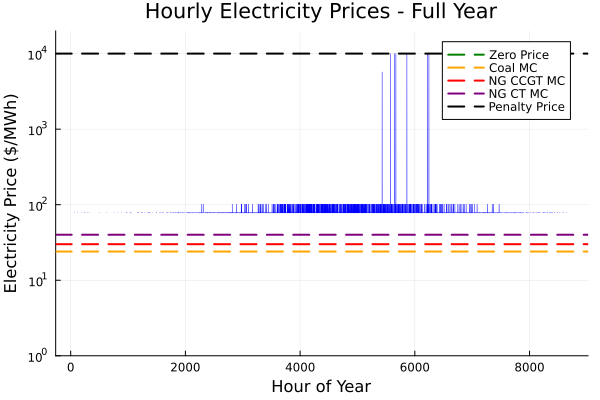

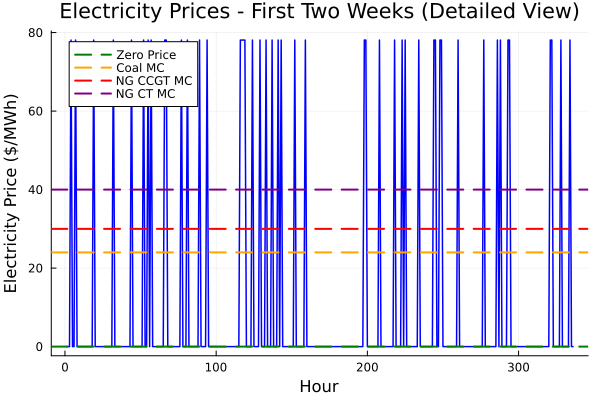

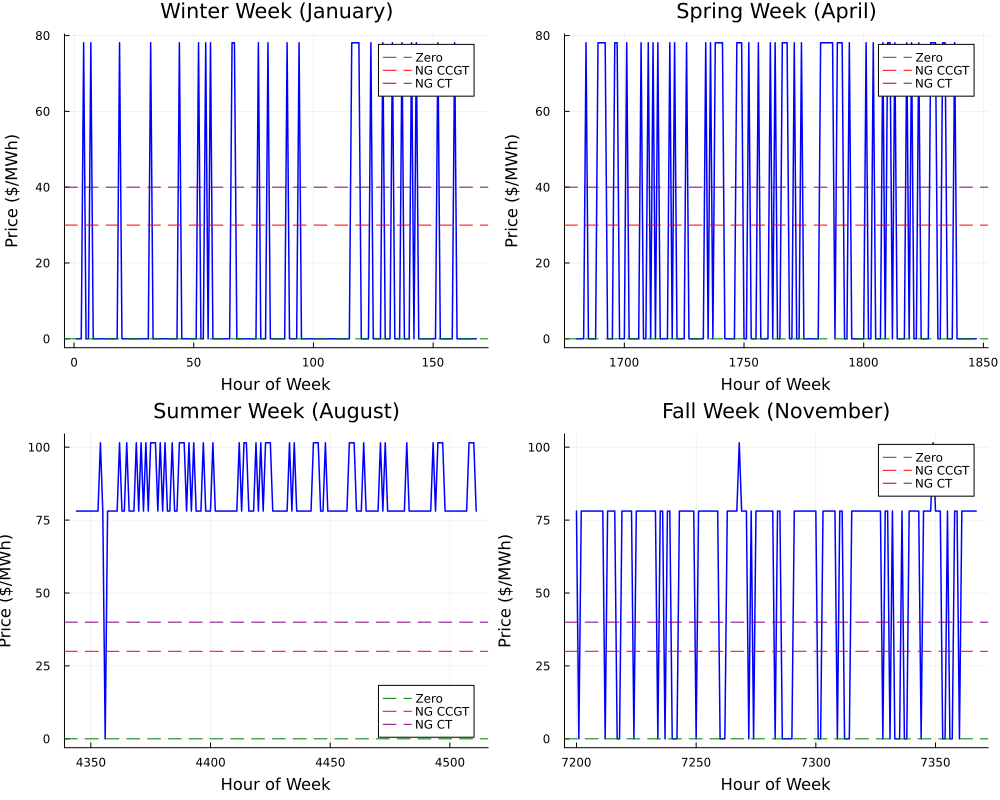


PROBLEM 3.4: ELECTRICITY PRICE PLOT

Basic Price Statistics:


┌ Warning: Invalid negative or zero value -0.0 found at series index 1 for log10 based yscale
└ @ Plots /Users/jinr_y/.julia/packages/Plots/8ZnR3/src/utils.jl:105
┌ Warning: Invalid negative or zero value -0.0 found at series index 1 for log10 based yscale
└ @ Plots /Users/jinr_y/.julia/packages/Plots/8ZnR3/src/utils.jl:105
┌ Warning: Invalid negative or zero value -0.0 found at series index 1 for log10 based yscale
└ @ Plots /Users/jinr_y/.julia/packages/Plots/8ZnR3/src/utils.jl:105


Average Price: $59.67/MWh
Zero Price Hours: 3116 (35.6%)
Penalty Price Hours: 6 (0.1%)

Plots saved as 'electricity_prices_full_year.png' and 'electricity_prices_first_two_weeks.png'


┌ Warning: Invalid negative or zero value -0.0 found at series index 1 for log10 based yscale
└ @ Plots /Users/jinr_y/.julia/packages/Plots/8ZnR3/src/utils.jl:105


In [60]:
# Problem 3.4: Electricity Price Plot
println("\n" * "="^50)
println("PROBLEM 3.4: ELECTRICITY PRICE PLOT")
println("="^50)

# Extract electricity prices (shadow prices of load balance constraints)
electricity_prices = [dual(load[t]) for t in 1:8760]

# Create the main price plot
p1 = plot(1:8760, electricity_prices,
    xlabel="Hour of Year", 
    ylabel="Electricity Price (\$/MWh)",  # Fixed: escaped $ character
    title="Hourly Electricity Prices - Full Year",
    label=false,
    linewidth=0.5,
    color=:blue,
    yscale=:log10,  # Use log scale to better visualize price variations
    ylims=(1, 20000))

# Add horizontal lines for key price levels
hline!([0.1], color=:green, linestyle=:dash, linewidth=2, label="Zero Price")
hline!([24], color=:orange, linestyle=:dash, linewidth=2, label="Coal MC")
hline!([30], color=:red, linestyle=:dash, linewidth=2, label="NG CCGT MC")
hline!([40], color=:purple, linestyle=:dash, linewidth=2, label="NG CT MC")
hline!([10000], color=:black, linestyle=:dash, linewidth=2, label="Penalty Price")

display(p1)

# Create a detailed view of first two weeks (336 hours)
p2 = plot(1:336, electricity_prices[1:336],
    xlabel="Hour", 
    ylabel="Electricity Price (\$/MWh)",  # Fixed: escaped $ character
    title="Electricity Prices - First Two Weeks (Detailed View)",
    label=false,
    linewidth=1.5,
    color=:blue)

# Mark different price levels
hline!([0], color=:green, linestyle=:dash, linewidth=2, label="Zero Price")
hline!([24], color=:orange, linestyle=:dash, linewidth=2, label="Coal MC")
hline!([30], color=:red, linestyle=:dash, linewidth=2, label="NG CCGT MC") 
hline!([40], color=:purple, linestyle=:dash, linewidth=2, label="NG CT MC")

display(p2)

# Create seasonal comparison (4 representative weeks)
representative_weeks = [
    (1:168, "Winter Week (January)"),
    (1680:1847, "Spring Week (April)"), 
    (4344:4511, "Summer Week (August)"),
    (7200:7367, "Fall Week (November)")
]

p3 = plot(layout=(2,2), size=(1000, 800))

for (i, (week_hours, title)) in enumerate(representative_weeks)
    plot!(p3[i], week_hours, electricity_prices[week_hours],
        title=title,
        xlabel="Hour of Week",
        ylabel="Price (\$/MWh)",  # Fixed: escaped $ character
        label=false,
        linewidth=1.5,
        color=:blue)
    
    # Add marginal cost lines
    hline!(p3[i], [0], color=:green, linestyle=:dash, linewidth=1, label="Zero")
    hline!(p3[i], [30], color=:red, linestyle=:dash, linewidth=1, label="NG CCGT")
    hline!(p3[i], [40], color=:purple, linestyle=:dash, linewidth=1, label="NG CT")
end

display(p3)

# Print basic statistics for the discussion
println("\nBasic Price Statistics:")
println("Average Price: \$", round(mean(electricity_prices); digits=2), "/MWh")  # Fixed: escaped $ character
println("Zero Price Hours: ", count(≈(0), electricity_prices), " (", round(count(≈(0), electricity_prices)/8760*100; digits=1), "%)")
println("Penalty Price Hours: ", count(≈(10000), electricity_prices), " (", round(count(≈(10000), electricity_prices)/8760*100; digits=1), "%)")

# Save the main plot
savefig(p1, "electricity_prices_full_year.png")
savefig(p2, "electricity_prices_first_two_weeks.png")
println("\nPlots saved as 'electricity_prices_full_year.png' and 'electricity_prices_first_two_weeks.png'")

**Problem 3.4 answer:**

The hourly electricity price results, obtained from the dual values of the load-balance constraints, show that most hours of the year have market-clearing prices between $20 and $60 /MWh, consistent with the marginal costs of coal and natural-gas combined-cycle units. Occasional zero-price hours occur when wind and solar generation exceed demand, while several price spikes near the $10 000 /MWh penalty indicate unserved energy during peak summer hours.

Seasonal plots confirm this hypothesis: winter and spring display many low-price hours due to renewable availability, whereas summer experiences sustained high prices when gas turbines become the marginal source. Overall, the price dynamics follow the merit-order dispatch logic and reveal both renewable curtailment periods and reliability stress events.

In [64]:
# Problem 3.5: CO₂ Shadow Price Analysis
println("\n" * "="^50)
println("PROBLEM 3.5: CO₂ SHADOW PRICE ANALYSIS")
println("="^50)

# Extract the shadow price of the CO₂ emissions constraint using JuMP
co2_shadow_price = dual(emissions_limit)

println("Shadow Price of CO₂: \$", round(co2_shadow_price; digits=2), " per tCO₂")
println("This means: Each additional ton of CO₂ emissions allowed would reduce total costs by \$", round(co2_shadow_price; digits=2))

# Calculate the value of allowing an additional 1000 tCO₂/yr
value_1000_tCO2 = 1000 * co2_shadow_price
println("Value of allowing additional 1000 tCO₂/yr: \$", round(value_1000_tCO2; digits=2))


PROBLEM 3.5: CO₂ SHADOW PRICE ANALYSIS
Shadow Price of CO₂: $-111.85 per tCO₂
This means: Each additional ton of CO₂ emissions allowed would reduce total costs by $-111.85
Value of allowing additional 1000 tCO₂/yr: $-111851.21


## References

List any external references consulted, including classmates.